# Complex Contagion on Watts–Strogatz Networks
### CITS4403 Computational Modelling — Raed

**What this models:** how a behaviour spreads through a social network.
People adopt a behaviour when enough of their friends already have.

**Baseline reproduced:** Centola & Macy (2007), *Complex Contagions and the
Weakness of Long Ties*.

**Key idea — two kinds of spreading:**
- **Simple contagion** — one contact is enough (like a rumour or a cold).
- **Complex contagion** — you need *several* friends to adopt before you do
  (like joining a movement or buying a costly new gadget).

**The question:** as we rewire a Watts–Strogatz network from a clustered ring
(p≈0) toward a random graph (p=1), does the behaviour spread better with
**clustering** or with **long-range shortcuts** — and does it depend on which
kind of contagion it is?

Run the cells top to bottom with **Shift+Enter**.

## 1. Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## 2. The contagion model

A node adopts once the **fraction** of its neighbours that have adopted is
**≥ θ (theta)**.

- small θ (e.g. 0.10 = 1 of 10 neighbours) → **simple** contagion
- larger θ (e.g. 0.30 = 3 of 10 neighbours) → **complex** contagion

We keep updating everyone until a full pass changes nobody — that's the
**steady state**. Then we return the fraction of the network that adopted
(the **cascade size**).

In [2]:
def run_contagion(G, theta, seed_nodes, max_steps=1000):
    """Run threshold contagion to steady state. Returns fraction adopted."""
    adopted = {node: False for node in G.nodes()}
    for s in seed_nodes:
        adopted[s] = True

    for step in range(max_steps):
        newly_adopted = []
        for node in G.nodes():
            if adopted[node]:
                continue
            nbrs = list(G.neighbors(node))
            if not nbrs:
                continue
            frac_active = sum(adopted[n] for n in nbrs) / len(nbrs)
            if frac_active >= theta:
                newly_adopted.append(node)
        if not newly_adopted:
            break                       # steady state reached
        for node in newly_adopted:
            adopted[node] = True

    return sum(adopted.values()) / G.number_of_nodes()

## 3. Seeding

Complex contagions need a **local cluster** to get started, not scattered
individuals. So we seed one node plus its neighbours.

In [3]:
def seed_cluster(G, size):
    """A small connected starting cluster: a node and its neighbours."""
    start = list(G.nodes())[0]
    cluster = {start}
    for n in G.neighbors(start):
        cluster.add(n)
        if len(cluster) >= size:
            break
    return list(cluster)

## 4. The core experiment: fix θ, sweep p

For each rewiring probability **p**, build several Watts–Strogatz graphs, run
the contagion on each, and average the final cascade size. We repeat many
times per p because the graphs are random — averaging gives a stable curve
and error bars.

In [4]:
def sweep_rewiring(n, k, theta, p_values, n_trials, seed_size):
    means, stds = [], []
    for p in p_values:
        results = []
        for _ in range(n_trials):
            G = nx.watts_strogatz_graph(n, k, p)
            seeds = seed_cluster(G, seed_size)
            results.append(run_contagion(G, theta, seeds))
        means.append(np.mean(results))
        stds.append(np.std(results))
    return np.array(means), np.array(stds)

## 5. Run it — three thresholds

We run **three** values of θ so we can see the full picture:
- θ = 0.10 → simple contagion
- θ = 0.20 → in between (the transition)
- θ = 0.30 → complex contagion

Each one sweeps p from 0.0001 (clustered ring) to 1 (random).
*(Takes about 1–2 minutes.)*

In [5]:
# --- parameters (our stated assumptions) ---
n = 500          # number of nodes (people)
k = 10           # each node connected to k nearest neighbours
seed_size = 12   # size of the initial adopted cluster
n_trials = 20    # repeats per p value (averaging + error bars)

p_values = np.logspace(-4, 0, 12)   # 0.0001 ... 1.0

thetas = [0.10, 0.20, 0.30]
labels = ['Simple (θ=0.10)', 'Intermediate (θ=0.20)', 'Complex (θ=0.30)']

results = {}
for theta, label in zip(thetas, labels):
    print(f"Running {label} ...")
    means, stds = sweep_rewiring(n, k, theta, p_values, n_trials, seed_size)
    results[label] = (means, stds)
print("Done.")

Running Simple (θ=0.10) ...


Running Intermediate (θ=0.20) ...


Running Complex (θ=0.30) ...


Done.


## 6. Plot the result

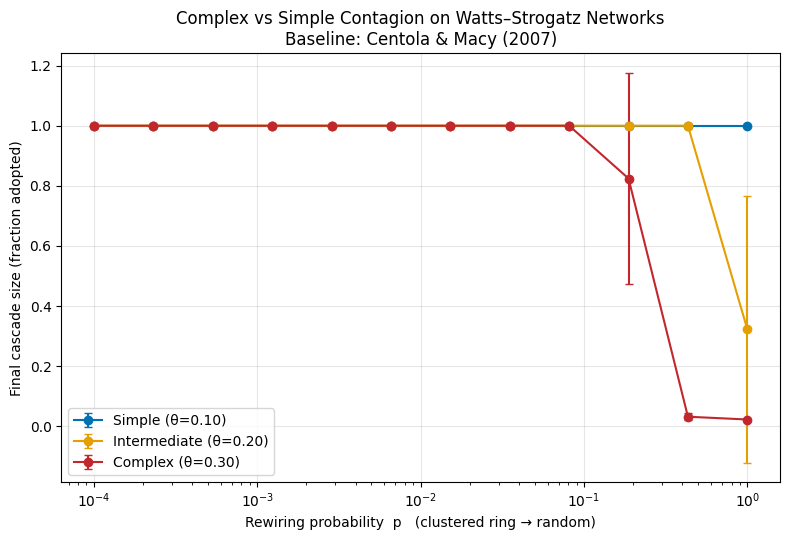

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#0072b2', '#e69f00', '#c1272d']

for (label, (means, stds)), c in zip(results.items(), colors):
    ax.errorbar(p_values, means, yerr=stds, marker='o', capsize=3,
                label=label, color=c)

ax.set_xscale('log')
ax.set_xlabel('Rewiring probability  p   (clustered ring → random)')
ax.set_ylabel('Final cascade size (fraction adopted)')
ax.set_title('Complex vs Simple Contagion on Watts–Strogatz Networks\n'
             'Baseline: Centola & Macy (2007)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('contagion_result.png', dpi=130)
plt.show()

## 7. What the result shows

- **Simple contagion (blue, θ=0.10):** spreads across the whole network at
  **every** p. One contact is enough, so long-range shortcuts don't hurt it —
  if anything they help.
- **Complex contagion (red, θ=0.30):** spreads fully while the network is
  **clustered** (low p), then **collapses** as p rises and shortcuts replace
  clustering. Complex contagion needs local reinforcement, which shortcuts
  destroy.
- **Intermediate (orange, θ=0.20):** sits between the two — its collapse
  begins earlier/later than the complex case, showing the transition depends
  on the threshold.

This reproduces **Centola & Macy (2007)**: *long-range ties impede complex
contagion.* Clustering provides the multiple reinforcements complex behaviours
need; random shortcuts do not.

The sharp drop in the red curve is a **phase transition** — a small change in p
flips the whole system from full spread to no spread. Sharp transitions like
this are a signature of complex systems (compare the connectivity S-curve in
Lecture 3).

## 8. Next steps (my extension)

The baseline above is deterministic and uses one θ for everyone. My planned
extension:
1. **Noisy thresholds** — nodes sometimes adopt below θ or resist above it.
   Recent work suggests noise can *reverse* the 2007 result; I'll test where.
2. **Heterogeneous thresholds** — different nodes draw different θ.

I'll map cascade size over a 2D **phase diagram** (p × noise) to locate where
clustering stops being an advantage. **Stretch:** repeat on a Barabási–Albert
scale-free network to test the role of hubs.

---
# Extension 1 — Heterogeneous thresholds

**Baseline assumption we're relaxing:** Centola & Macy give *every* node the
same threshold. Real populations are mixed — some people are easily influenced
(low threshold), some are resistant (high threshold).

**What we change:** each node gets its *own* threshold, drawn from a normal
distribution with a fixed **mean** but an adjustable **spread** (standard
deviation). Spread = 0 reproduces the uniform baseline; larger spread = more
variation between people.

**Question:** holding the *average* threshold fixed, does more *variation* make
a complex contagion spread more, or less?

In [7]:
def run_contagion_hetero(G, thetas, seed_nodes, max_steps=1000):
    """Like run_contagion, but thetas is a dict: node -> its own threshold."""
    adopted = {node: False for node in G.nodes()}
    for s in seed_nodes:
        adopted[s] = True
    for _ in range(max_steps):
        newly = []
        for node in G.nodes():
            if adopted[node]:
                continue
            nbrs = list(G.neighbors(node))
            if not nbrs:
                continue
            frac = sum(adopted[n] for n in nbrs) / len(nbrs)
            if frac >= thetas[node]:          # compare to THIS node's threshold
                newly.append(node)
        if not newly:
            break
        for node in newly:
            adopted[node] = True
    return sum(adopted.values()) / G.number_of_nodes()


def assign_thresholds(G, mean_theta, spread, rng):
    """Each node's threshold ~ Normal(mean, spread), clipped to [0, 1]."""
    thetas = {}
    for node in G.nodes():
        val = rng.normal(mean_theta, spread)
        thetas[node] = min(1.0, max(0.0, val))
    return thetas

### Experiment: fix p and mean threshold, sweep the *spread*

We test at three rewiring probabilities. The interesting ones are the higher p
values (p=0.3, 0.5) — the randomised networks where, in the baseline, a uniform
complex contagion **dies**. If variation can revive it *there*, that's a real
effect. *(Takes a couple of minutes.)*

p=0.05 ...


p=0.3 ...


p=0.5 ...


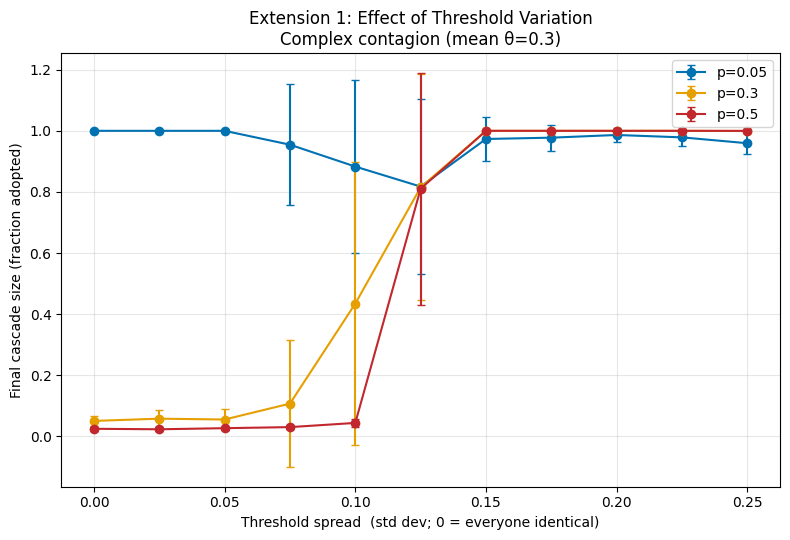

In [8]:
def sweep_spread(n, k, p, mean_theta, spread_values, n_trials, seed_size):
    means, stds = [], []
    rng = np.random.default_rng(42)
    for spread in spread_values:
        results = []
        for _ in range(n_trials):
            G = nx.watts_strogatz_graph(n, k, p)
            thetas = assign_thresholds(G, mean_theta, spread, rng)
            seeds = seed_cluster(G, seed_size)
            results.append(run_contagion_hetero(G, thetas, seeds))
        means.append(np.mean(results))
        stds.append(np.std(results))
    return np.array(means), np.array(stds)


mean_theta = 0.30                       # complex contagion, same avg as baseline
spread_values = np.linspace(0.0, 0.25, 11)   # 0 = uniform baseline
p_tests = [0.05, 0.3, 0.5]
colors = ['#0072b2', '#e69f00', '#c1272d']

fig, ax = plt.subplots(figsize=(8, 5.5))
for p, c in zip(p_tests, colors):
    print(f"p={p} ...")
    means, stds = sweep_spread(n, k, p, mean_theta,
                               spread_values, n_trials, seed_size)
    ax.errorbar(spread_values, means, yerr=stds, marker='o', capsize=3,
                color=c, label=f'p={p}')

ax.set_xlabel('Threshold spread  (std dev; 0 = everyone identical)')
ax.set_ylabel('Final cascade size (fraction adopted)')
ax.set_title('Extension 1: Effect of Threshold Variation\n'
             f'Complex contagion (mean θ={mean_theta})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('ext1_result.png', dpi=130)
plt.show()

### What Extension 1 shows

- **p = 0.05 (blue, clustered):** already spreads fully in the baseline, so
  variation barely changes it — stays near 1.0.
- **p = 0.3 and p = 0.5 (orange, red — randomised networks):** with everyone
  identical (spread = 0) the complex contagion **dies** (~0.03–0.07, matching
  the baseline collapse). But as threshold variation increases, it **revives**,
  reaching full spread by spread ≈ 0.15 — on the *same* graphs where the
  uniform version failed.

**Interpretation:** a mixed population contains a few easily-influenced
"early adopters" (low-threshold nodes). They adopt off a single distant
contact, which then gives *their* neighbours the extra reinforcement they
needed — reigniting a cascade that a uniform population blocks. This is
Granovetter's early-adopter idea appearing in the model.

**Why it matters:** it *partially overturns* the baseline. Centola & Macy's
"long ties impede complex contagion" holds only when everyone is identical.
Add realistic variation and long-range shortcuts become usable again. The
transition is sharp (near-zero to full spread over a small change in spread) —
another phase transition, like the baseline.